# FIP 10 — DA, NE and movement: correlation and coherence over the session

How closely do DA, NE and movement (ME) co-vary over a session, at what lag, and on which
timescales?

1. **DA × NE in every session** (97 sessions): cross-correlation and coherence.
2. **DA–NE, DA–ME and NE–ME** in the sessions with a usable bottom camera (88): one session, the
   summary over animals, each signal against ME per animal, and coherence by frequency band.
3. Numbers

**Signals.** DA: dLight in lateral NAc (`latNAcc(X)-DA`). NE: GCaMP in LC noradrenergic axons
imaged in PL (`PL(X)-LCAxonCa`), i.e. axonal calcium. Both are `dff-bright_mc-iso-IRLS` dF/F at
20 Hz. The two indicators have different kinetics, so lags describe the recorded signals, not
timing in the brain.

**Movement** is motion energy (ME) from the bottom camera: the summed absolute frame-to-frame pixel
change, from the aligned ME table (`fip_motion_energy_aligned`, frame times corrected by the video
timing QC). Cameras that fail the video timing or quality screen are left out (`men_01`).

**Data.** The CSV-curated `DANE_3channels_curated` and `DANE_4channels_curated` assets. Each animal
contributes one hemisphere (the side with more sessions), with DA and NE from that side; animals
need at least 3 sessions (`fu.inventory_pairs`, `fu.choose_side`, `fu.load_pairs`). Traces sit on
one 20 Hz grid from 5 s before the first go cue to 10 s after the last; ME is averaged into the same
bins (`fu.add_motion_energy`). Each trace is z-scored over the session.

**Statistics.** Session values are averaged within animal; tests are Wilcoxon signed-rank on animal
means (smallest two-sided p with 9 animals: 0.004). Error bands are SEM over animals.

**Tests per session.** Normalized cross-correlation within ±3 s (`su.xcorr_shift_null(a, b)`) and
magnitude-squared coherence (Welch, 51.2-s segments), each against 200 circular shifts of *b* by at
least 60 s, which keep each trace's autocorrelation and remove their alignment.

**Conventions.** + lag = the first-named signal of a pair later, except DA–NE, where + = NE later
(DA–ME + = DA later; NE–ME + = NE later). Colors: DA vermillion, NE blue, ME dark grey; pairs DA–NE
purple, DA–ME vermillion, NE–ME blue.

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import fip_utils as fu
import signal_utils as su
import stats_utils as st
import plot_utils as pu
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
PAIRS_CACHE = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO
               else "../../data/fip_05_cache/pairs.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

# ── Data ─────────────────────────────────────────────────────────────────────
FS = 20.0                  # Hz, the common grid
CAMERA = "BottomCamera"
MIN_SESSIONS_PER_ANIMAL = 3
EXCLUDE_SUBJECTS = ()      # QC decides; none excluded

# ── Cross-correlation and coherence ──────────────────────────────────────────
MAXLAG_S = 3.0
N_SHIFT = 200              # circular shifts per session
MIN_SHIFT_S = 60.0         # smallest circular shift
COH_NPERSEG = 1024         # 51.2-s Welch segments
COH_BAND_HZ = (0.02, 2.0)  # coherence band tested; DA power at 2 Hz is ~1% of its low-frequency power
# coherence by band (section 2): slow/state, trial rate (~0.15 Hz), within trial. The first band
# starts at the first non-zero Welch bin (1 / 51.2 s ≈ 0.0195 Hz); bins are [lo, hi).
COH_BANDS = {"0.02–0.1 Hz": (1 / 51.2, 0.1), "0.1–0.5 Hz": (0.1, 0.5), "0.5–2 Hz": (0.5, 2.0)}
PAIRS = [("ne", "da"), ("da", "me"), ("ne", "me")]   # (a, b): + lag = a later than b
EXAMPLE_SESSION = "800886_2025-09-03"   # the session whose DA–NE peak r is closest to the median
EXAMPLE_WINDOW_S, EXAMPLE_ZOOM_S = 180.0, 20.0

# ── Colors ───────────────────────────────────────────────────────────────────
SIG = ("da", "ne", "me")
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"], "me": "0.25"}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)", "me": "ME (bottom camera)"}
OUT_COLOR = {"rewarded": OKABE_ITO["orange"], "unrewarded": "0.55"}
NULL_COLOR = PALETTE["not_sig"]
TOTAL_COLOR = "k"
PAIR_KEY = {pr: f"{pr[0]}_{pr[1]}" for pr in PAIRS}
PAIR_LABEL = {("ne", "da"): "DA–NE", ("da", "me"): "DA–ME", ("ne", "me"): "NE–ME"}
PAIR_COLOR = {("ne", "da"): OKABE_ITO["reddish_purple"], ("da", "me"): OKABE_ITO["vermillion"],
              ("ne", "me"): OKABE_ITO["blue"]}
CUE = "goCue_start_time_in_session"
rng = np.random.default_rng(0)

## 0. Data

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

inv = fu.inventory_pairs(asset_roots)
kept, side_table = fu.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
pairs = fu.load_pairs(kept, fs=FS, cache_path=PAIRS_CACHE)
for p in pairs:
    p["z"] = {s: su.zscore(p[s]) for s in ("da", "ne")}
    p["t"] = p["t0"] + np.arange(len(p["da"])) / FS
me_pairs = fu.add_motion_energy(pairs, kept, CAMERA, ME_DATA_ROOT, onset_fs=None,
                                exclude_subjects=EXCLUDE_SUBJECTS)

SUBJECTS = sorted({p["subject"] for p in pairs})
N_ANIMALS = len(SUBJECTS)
PAIR_SUBJECTS = [p["subject"] for p in pairs]
ME_SUBJECTS = [p["subject"] for p in me_pairs]
N_ME_ANIMALS = len(set(ME_SUBJECTS))
print(f"{len(pairs)} sessions from {N_ANIMALS} animals; {len(me_pairs)} with bottom-camera ME "
      f"({N_ME_ANIMALS} animals)")
pd.DataFrame({"sessions": pd.Series(PAIR_SUBJECTS).value_counts(),
              "with ME": pd.Series(ME_SUBJECTS).value_counts()}).fillna(0).astype(int).T

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl


97 sessions from 9 animals; 88 with bottom-camera ME (9 animals)


,800886,808054,809487,809491,815334,816212,816214,818585,818586
sessions,5,16,8,20,4,8,5,8,23
with ME,4,15,8,19,3,5,5,7,22


In [4]:
ANIMAL_STYLE = pu.animal_styles(SUBJECTS)


def per_animal(df, effect, p=None, z=None):
    """Per animal: sessions, median and range of `effect` across sessions, and per-session test summary.

    With `z` (a per-session z-score against a shift null) the median and range of z are given; the
    shift tests' p-values sit at their floor, so their range is not shown."""
    rows = []
    for subj, g in df.groupby("subject"):
        e = g[effect].dropna()
        r = dict(subject=subj, n_sessions=len(e), median=e.median(), min=e.min(), max=e.max())
        if p is not None:
            pv = g.loc[e.index, p]
            r["frac_p_lt_05"] = (pv < 0.05).mean()
            if z is None:
                r.update(p_min=pv.min(), p_max=pv.max())
        if z is not None:
            zv = g.loc[e.index, z]
            r.update(z_median=zv.median(), z_min=zv.min(), z_max=zv.max())
        rows.append(r)
    return pd.DataFrame(rows).set_index("subject")


def show_per_animal(title, df, effect, p=None, z=None, digits=3):
    """Print the per-animal table and the across-animal Wilcoxon on animal means."""
    t = per_animal(df, effect, p, z)
    m, pv, n = st.wilcoxon_animals(df.groupby("subject")[effect].mean())
    print(f"── {title} ── mean of animal means {m:+.3f}, Wilcoxon p = {pv:.4f} (n = {n})")
    fmt = {c: (lambda v: f"{v:.2g}") for c in ("p_min", "p_max")}
    fmt.update({c: (lambda v: f"{v:.1f}") for c in ("z_median", "z_min", "z_max")})
    print(t.to_string(float_format=lambda v: f"{v:.{digits}f}", formatters=fmt))
    print()


def report(title, df, cols):
    # mean ± SEM over animals and Wilcoxon p against zero, one row per column of an animal table
    rows = []
    for c in cols:
        m, p, n = st.wilcoxon_animals(df[c])
        rows.append(dict(measure=c, mean=m, sem=df[c].std(ddof=1) / np.sqrt(df[c].notna().sum()),
                         p=p, n=n))
    print(f"── {title}")
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3g}"))
    print()

## 1. DA × NE in every session

Per session (all 97): the normalized cross-correlation of the two z-scored traces within ±3 s
(`su.norm_xcorr(ne, da)`; positive lag = NE later) and magnitude-squared coherence (Welch, 51.2-s
segments). The null is 200 circular shifts of NE against DA by at least 60 s, which keep each
trace's autocorrelation and remove their alignment.

- **Cross-correlation test.** Peak |r| against the null's peak |r|; effect size = peak |r| minus
  the null median.
- **Coherence test.** Mean coherence over 0.02–2 Hz against the same mean for each shift; effect
  size = observed minus the null median. Above 2 Hz both signals carry little power (DA at 2 Hz is
  ~1% of its low-frequency power, at 5 Hz ~10⁻⁵).
- p = (1 + number of shifts ≥ observed) / 201, so the smallest per-session p is 0.005. Each session
  also gets z = (observed − null mean) / null SD, which grades sessions whose p is at that floor.

In [5]:
K_LAG = int(round(MAXLAG_S * FS))
LAGS = np.arange(-K_LAG, K_LAG + 1) / FS

rows = []
for p in pairs:
    da, ne = p["z"]["da"], p["z"]["ne"]
    _, cc, null = su.xcorr_shift_null(ne, da, FS, MAXLAG_S, N_SHIFT, MIN_SHIFT_S, rng)  # + lag = NE later
    f_coh, coh, coh_null = su.coherence_shift_null(da, ne, FS, COH_NPERSEG, N_SHIFT, MIN_SHIFT_S, rng)
    in_band = (f_coh >= COH_BAND_HZ[0]) & (f_coh <= COH_BAND_HZ[1])
    k = int(np.argmax(np.abs(cc)))
    null_peaks = np.abs(null).max(1)
    band_obs, band_null = coh[in_band].mean(), coh_null[:, in_band].mean(1)
    p.update(xc=cc, xc_null=null, coh=coh, coh_null=coh_null)
    rows.append(dict(subject=p["subject"], session=p["session"], peak_r=cc[k], peak_lag=LAGS[k],
                     r0=cc[K_LAG], null_peak=np.median(null_peaks),
                     null_peak_95=np.percentile(null_peaks, 95),
                     peak_r_effect=abs(cc[k]) - np.median(null_peaks),
                     p_xc=st.shift_p(abs(cc[k]), null_peaks), z_xc=st.shift_z(abs(cc[k]), null_peaks),
                     coh_band=band_obs, coh_null=np.median(band_null),
                     coh_effect=band_obs - np.median(band_null), p_coh=st.shift_p(band_obs, band_null),
                     z_coh=st.shift_z(band_obs, band_null)))
xc_sess = pd.DataFrame(rows)
IN_F = (f_coh >= COH_BAND_HZ[0]) & (f_coh <= COH_BAND_HZ[1])

# Grand means over animals, and the per-animal curves
xc_animal = st.group_means([p["xc"] for p in pairs], PAIR_SUBJECTS)[1]
xc_null_grand = st.group_means([p["xc_null"] for p in pairs], PAIR_SUBJECTS)[1].mean(0)
coh_animal = st.group_means([p["coh"] for p in pairs], PAIR_SUBJECTS)[1]
coh_null_grand = st.group_means([p["coh_null"] for p in pairs], PAIR_SUBJECTS)[1].mean(0)
coh_thr = np.percentile(coh_null_grand, 95, axis=0)

xc_by_animal = st.animal_means(xc_sess, ["peak_r", "peak_lag", "r0", "null_peak", "peak_r_effect",
                                         "coh_band", "coh_effect"], by_session=False)
k_an = np.argmax(np.abs(xc_animal), 1)
ANIMAL_ORDER = list(xc_by_animal["peak_r"].sort_values().index)
k_g = int(np.argmax(np.abs(xc_animal.mean(0))))
print(f"grand-mean cross-correlation: peak r = {xc_animal.mean(0)[k_g]:+.3f} at {LAGS[k_g]:+.2f} s\n")
show_per_animal("peak r", xc_sess, "peak_r", "p_xc", "z_xc")
show_per_animal("peak |r| minus shift-null median", xc_sess, "peak_r_effect", "p_xc", "z_xc")
show_per_animal("peak lag (s, + = NE later)", xc_sess, "peak_lag")
show_per_animal("coherence 0.02–2 Hz", xc_sess, "coh_band", "p_coh", "z_coh")
show_per_animal("coherence 0.02–2 Hz minus shift-null median", xc_sess, "coh_effect", "p_coh", "z_coh")

grand-mean cross-correlation: peak r = +0.265 at +0.05 s

── peak r ── mean of animal means +0.272, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min   max  frac_p_lt_05 z_median z_min z_max
subject                                                                    
800886            5   0.306  0.281 0.339         1.000     37.5  27.6  40.1
808054           16   0.272  0.212 0.340         1.000     28.6  23.7  36.6
809487            8   0.182  0.116 0.304         1.000     17.1  11.3  27.6
809491           20   0.342  0.257 0.521         1.000     46.8  20.5  62.2
815334            4   0.350  0.336 0.437         1.000     47.3  34.3  56.1
816212            8   0.090 -0.300 0.135         1.000     11.5   2.9  18.9
816214            5   0.354  0.313 0.422         1.000     34.0  20.1  39.2
818585            8   0.250  0.066 0.290         1.000     32.7   5.2  44.2
818586           23   0.317  0.257 0.395         1.000     36.2  24.1  45.0

── peak |r| minus shift-null median

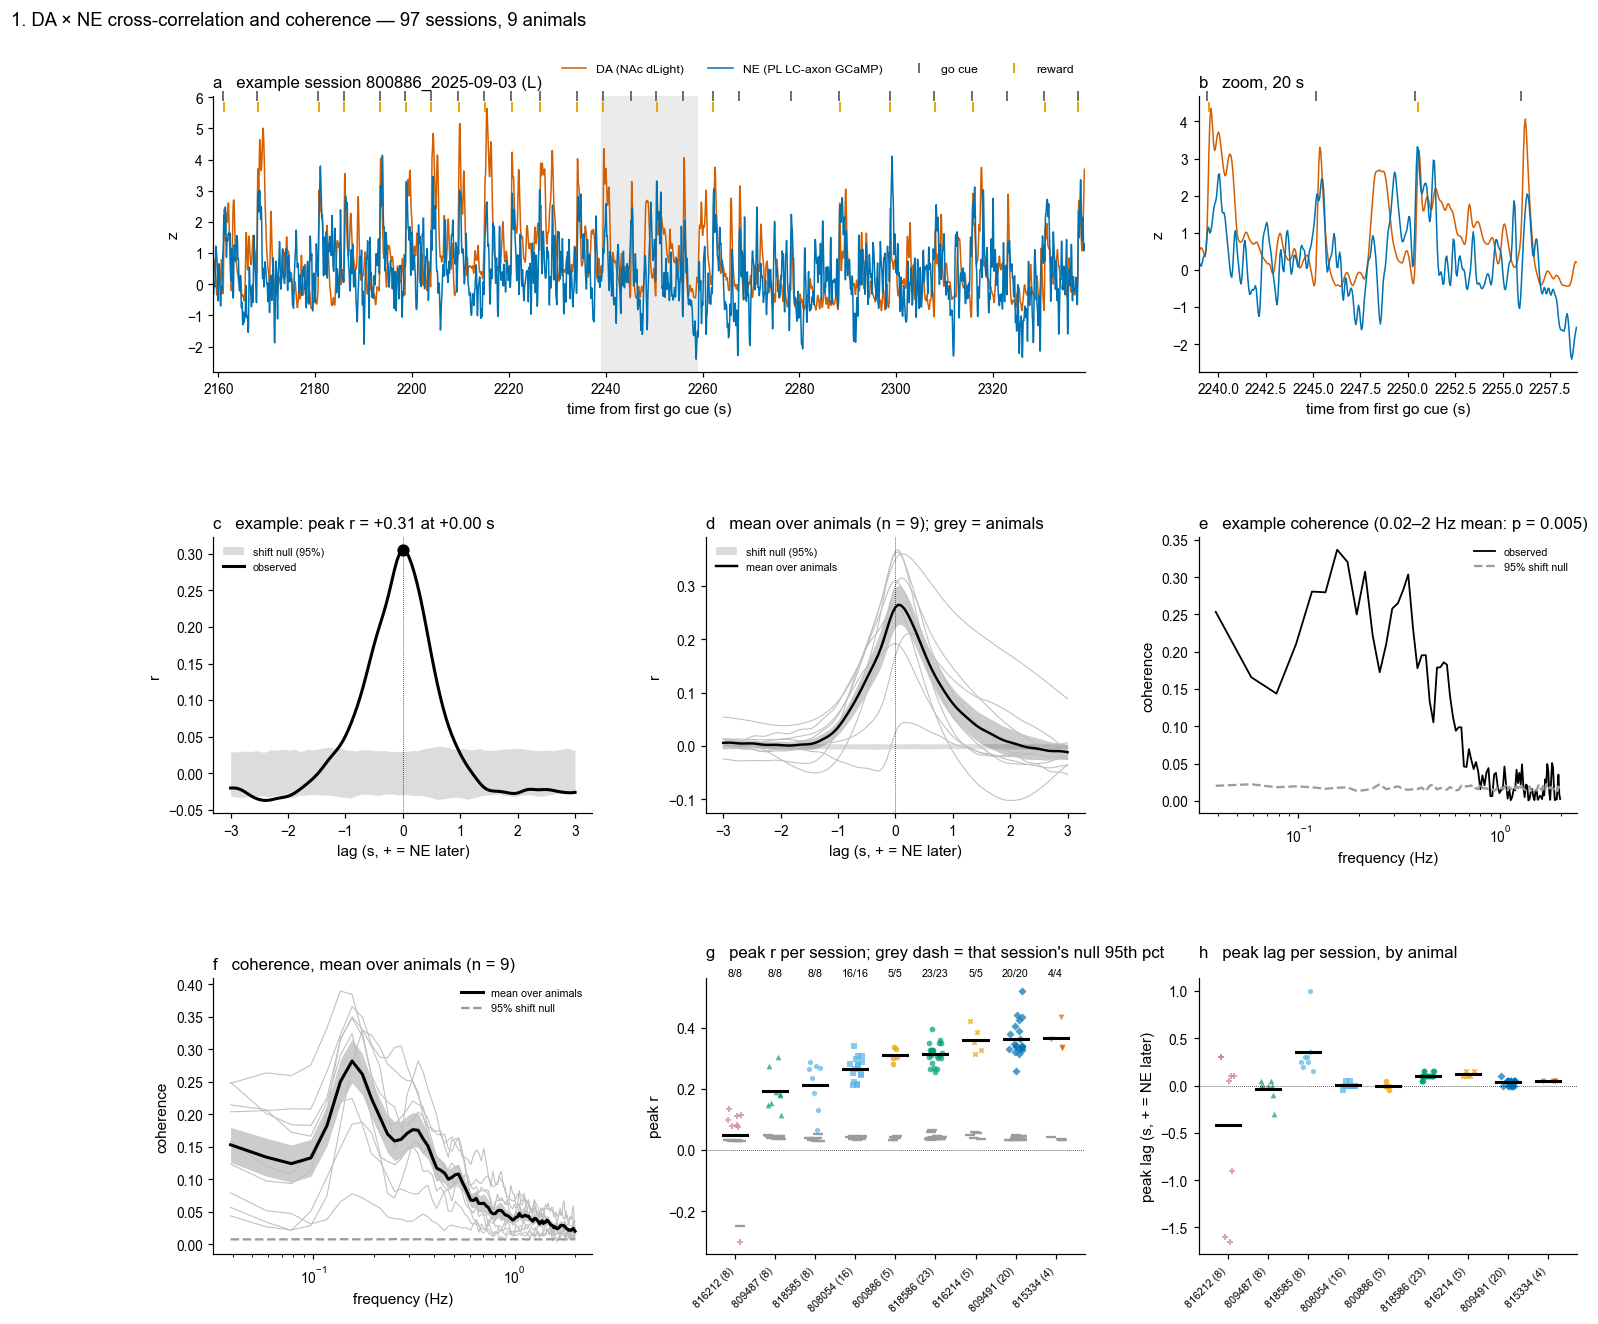

In [6]:
names = [p["session"] for p in pairs]
ex_i = (names.index(EXAMPLE_SESSION) if EXAMPLE_SESSION in names
        else int(np.argmin(np.abs(xc_sess.peak_r - xc_sess.peak_r.median()))))
ex = pairs[ex_i]
ex_row = xc_sess.iloc[ex_i]
ex_thr = np.percentile(ex["coh_null"], 95, axis=0)
t_mid = 0.5 * (ex["t"][0] + ex["t"][-1])
win_a = (t_mid - EXAMPLE_WINDOW_S / 2, t_mid + EXAMPLE_WINDOW_S / 2)
win_z = (t_mid - EXAMPLE_ZOOM_S / 2, t_mid + EXAMPLE_ZOOM_S / 2)


def plot_traces(ax, p, win, shade=None, legend=False):
    m = (p["t"] >= win[0]) & (p["t"] < win[1])
    for s in ("da", "ne"):
        ax.plot(p["t"][m], p["z"][s][m], color=SIG_COLOR[s], lw=1.0, label=SIG_LABEL[s])
    tr = p["trials"]
    for col, sel, c, lab in ((CUE, np.ones(len(tr), bool), PALETTE["neutral"], "go cue"),
                             ("reward_outcome_time_in_session", tr["earned_reward"].astype(bool),
                              OUT_COLOR["rewarded"], "reward")):
        t = tr.loc[sel, col].dropna().to_numpy()
        t = t[(t >= win[0]) & (t < win[1])]
        ax.plot(t, np.full(len(t), 1.0 if lab == "go cue" else 0.96), "|", color=c, ms=7, mew=1.2,
                label=lab, transform=ax.get_xaxis_transform(), clip_on=False)
    if shade:
        ax.axvspan(*shade, color=NULL_COLOR, alpha=0.2, lw=0)
    ax.set_xlim(win)
    ax.set_xlabel("time from first go cue (s)")
    ax.set_ylabel("z")
    if legend:
        ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.04), ncol=4, frameon=False, fontsize=8)
    style_ax(ax)


fig = plt.figure(figsize=(16, 13))
gs = GridSpec(3, 3, figure=fig, hspace=0.6, wspace=0.3, top=0.92)

ax = fig.add_subplot(gs[0, :2])
plot_traces(ax, ex, win_a, shade=win_z, legend=True)
ax.set_title(f"a   example session {ex['session']} ({ex['side']})", loc="left")
ax = fig.add_subplot(gs[0, 2])
plot_traces(ax, ex, win_z)
ax.set_title(f"b   zoom, {EXAMPLE_ZOOM_S:.0f} s", loc="left")

ax = fig.add_subplot(gs[1, 0])
lo, hi = np.percentile(ex["xc_null"], [2.5, 97.5], axis=0)
ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
ax.plot(LAGS, ex["xc"], color=TOTAL_COLOR, lw=2, label="observed")
ax.plot(ex_row.peak_lag, ex_row.peak_r, "o", color=TOTAL_COLOR, ms=7)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("lag (s, + = NE later)")
ax.set_ylabel("r")
ax.set_title(f"c   example: peak r = {ex_row.peak_r:+.2f} at {ex_row.peak_lag:+.2f} s", loc="left")
ax.legend(fontsize=7, loc="upper left")
style_ax(ax)

ax = fig.add_subplot(gs[1, 1])
lo, hi = np.percentile(xc_null_grand, [2.5, 97.5], axis=0)
ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
for i, c in enumerate(xc_animal):
    ax.plot(LAGS, c, color="0.75", lw=0.7)
pu.plot_mean_sem(ax, LAGS, list(xc_animal), TOTAL_COLOR, "mean over animals")
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("lag (s, + = NE later)")
ax.set_ylabel("r")
ax.set_title(f"d   mean over animals (n = {N_ANIMALS}); grey = animals", loc="left")
ax.legend(fontsize=7, loc="upper left")
style_ax(ax)

ax = fig.add_subplot(gs[1, 2])
ax.semilogx(f_coh[IN_F], ex["coh"][IN_F], color=TOTAL_COLOR, lw=1.2, label="observed")
ax.semilogx(f_coh[IN_F], ex_thr[IN_F], color=NULL_COLOR, lw=1.5, ls="--", label="95% shift null")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title(f"e   example coherence (0.02–2 Hz mean: p = {ex_row.p_coh:.3f})", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[2, 0])
for c in coh_animal:
    ax.semilogx(f_coh[IN_F], c[IN_F], color="0.75", lw=0.7)
pu.plot_mean_sem(ax, f_coh[IN_F], coh_animal[:, IN_F], TOTAL_COLOR, "mean over animals", lw=2)
ax.semilogx(f_coh[IN_F], coh_thr[IN_F], color=NULL_COLOR, lw=1.5, ls="--", label="95% shift null")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title(f"f   coherence, mean over animals (n = {N_ANIMALS})", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[2, 1])
pu.strip_by_animal(ax, xc_sess, "peak_r", ANIMAL_ORDER, "peak r", styles=ANIMAL_STYLE, null_col="null_peak_95", p_col="p_xc")
ax.set_title("g   peak r per session; grey dash = that session's null 95th pct", loc="left", pad=14)
ax = fig.add_subplot(gs[2, 2])
pu.strip_by_animal(ax, xc_sess, "peak_lag", ANIMAL_ORDER, "peak lag (s, + = NE later)", styles=ANIMAL_STYLE)
ax.set_title("h   peak lag per session, by animal", loc="left", pad=14)

fig.suptitle(f"1. DA × NE cross-correlation and coherence — {len(pairs)} sessions, "
             f"{N_ANIMALS} animals", x=0.01, ha="left")
save_fig(fig, "fip_10_1_da_ne", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 2. DA, NE and ME: each pair

Section 1's measures for all three pairs, on the 88 sessions with a usable bottom camera. Per session and pair: the
normalized cross-correlation within ±3 s (`su.xcorr_shift_null(a, b)`: + lag = *a* later) and
magnitude-squared coherence (Welch, 51.2-s segments), each against 200 circular shifts of *b* by at
least 60 s. Lag signs: DA–NE + = NE later; DA–ME + = DA later; NE–ME + = NE later.

- **Peak r**: the largest |r| within ±3 s, with its sign, and its lag. Effect = peak |r| minus the
  null's median peak |r|.
- **Coherence**: mean over 0.02–2 Hz (section 1's band) minus the same mean for the shift-null median.
  DA and NE carry little power above 2 Hz; ME carries more, so any ME coupling above 2 Hz is outside
  this measure.
- Pairs are compared with Wilcoxon signed-rank on the per-animal differences.
- A further figure splits coherence into three bands (`COH_BANDS`): 0.02–0.1 Hz (slow, state-like),
  0.1–0.5 Hz (around the trial rate) and 0.5–2 Hz (within trial), each against its own shift null.
  The single 0.02–2 Hz mean is dominated by its 0.2–2 Hz bins, because Welch bins are evenly spaced in Hz.

- A third figure draws DA × ME and NE × ME per animal (the same cross-correlations).

In [7]:
MEASURES = ["peak_r", "peak_lag", "r0", "peak_r_effect", "coh_band", "coh_effect"]

pair_rows = []
pair_curves = {pr: dict(xc=[], xc_null=[], coh=[], coh_null=[]) for pr in PAIRS}
for p in me_pairs:
    z = p["z"]
    for a, b in PAIRS:
        _, cc, null = su.xcorr_shift_null(z[a], z[b], FS, MAXLAG_S, N_SHIFT, MIN_SHIFT_S, rng)
        f_coh, coh, coh_null = su.coherence_shift_null(z[a], z[b], FS, COH_NPERSEG, N_SHIFT,
                                                       MIN_SHIFT_S, rng)
        in_band = (f_coh >= COH_BAND_HZ[0]) & (f_coh <= COH_BAND_HZ[1])
        k = int(np.argmax(np.abs(cc)))
        null_peaks = np.abs(null).max(1)
        band_obs, band_null = coh[in_band].mean(), coh_null[:, in_band].mean(1)
        c = pair_curves[(a, b)]
        c["xc"].append(cc)
        c["xc_null"].append(np.percentile(null, [2.5, 97.5], axis=0))
        c["coh"].append(coh)
        c["coh_null"].append(np.percentile(coh_null, 95, axis=0))
        pair_rows.append(dict(subject=p["subject"], session=p["session"], pair=PAIR_KEY[(a, b)],
                              peak_r=cc[k], peak_lag=LAGS[k], r0=cc[K_LAG],
                              peak_r_effect=abs(cc[k]) - np.median(null_peaks),
                              null_peak_95=np.percentile(null_peaks, 95),
                              p_xc=st.shift_p(abs(cc[k]), null_peaks),
                              coh_band=band_obs, coh_effect=band_obs - np.median(band_null),
                              p_coh=st.shift_p(band_obs, band_null)))
        for name, (lo, hi) in COH_BANDS.items():   # band split, for the band figure
            m = (f_coh >= lo - 1e-9) & (f_coh < hi)
            b_obs, b_null = coh[m].mean(), coh_null[:, m].mean(1)
            pair_rows[-1].update({f"coh[{name}]": b_obs, f"coh_effect[{name}]": b_obs - np.median(b_null),
                                  f"p_coh[{name}]": st.shift_p(b_obs, b_null)})
pair_sess = pd.DataFrame(pair_rows)
IN_F = (f_coh >= COH_BAND_HZ[0]) & (f_coh <= COH_BAND_HZ[1])

# one row per session, one column per measure × pair, then animal means
wide = pair_sess.pivot_table(index=["subject", "session"], columns="pair", values=MEASURES)
wide.columns = [f"{m}_{pk}" for m, pk in wide.columns]
pair_animal = st.animal_means(wide.reset_index(), list(wide.columns), by_session=False)

# animal-mean curves per pair
pair_xc = {pr: st.group_means(c["xc"], ME_SUBJECTS)[1] for pr, c in pair_curves.items()}
pair_coh = {pr: st.group_means(c["coh"], ME_SUBJECTS)[1] for pr, c in pair_curves.items()}
pair_xc_null = {pr: st.group_means(c["xc_null"], ME_SUBJECTS)[1].mean(0) for pr, c in pair_curves.items()}
pair_coh_null = {pr: st.group_means(c["coh_null"], ME_SUBJECTS)[1].mean(0) for pr, c in pair_curves.items()}

sig_frac = pair_sess.groupby("pair")[["p_xc", "p_coh"]].agg(lambda v: (v < 0.05).mean())
print("fraction of sessions above their shift null (p < 0.05)\n", sig_frac.round(2), "\n")
for m in MEASURES:
    report(m, pair_animal, [f"{m}_{PAIR_KEY[pr]}" for pr in PAIRS])

# pair against pair, per animal
cmp_rows = []
for m in ("peak_r", "coh_effect"):
    for i, x in enumerate(PAIRS):
        for y in PAIRS[i + 1:]:
            d = pair_animal[f"{m}_{PAIR_KEY[x]}"] - pair_animal[f"{m}_{PAIR_KEY[y]}"]
            mean, pv, n = st.wilcoxon_animals(d)
            cmp_rows.append(dict(measure=m, comparison=f"{PAIR_LABEL[x]} − {PAIR_LABEL[y]}",
                                 mean_diff=mean, p=pv, animals_positive=f"{int((d > 0).sum())}/{n}"))
pair_cmp = pd.DataFrame(cmp_rows)
print("── pair against pair (Wilcoxon on animal differences)")
print(pair_cmp.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

fraction of sessions above their shift null (p < 0.05)
        p_xc  p_coh
pair              
da_me   1.0    1.0
ne_da   1.0    1.0
ne_me   1.0    1.0 

── peak_r
     measure  mean    sem       p  n
peak_r_ne_da 0.265  0.037 0.00391  9
peak_r_da_me 0.326 0.0308 0.00391  9
peak_r_ne_me 0.627 0.0331 0.00391  9

── peak_lag
       measure    mean    sem       p  n
peak_lag_ne_da  0.0274 0.0662   0.301  9
peak_lag_da_me -0.0593 0.0716   0.484  9
peak_lag_ne_me   0.171 0.0596 0.00391  9

── r0
 measure  mean    sem       p  n
r0_ne_da 0.255 0.0389 0.00391  9
r0_da_me 0.308 0.0372 0.00391  9
r0_ne_me 0.581 0.0296 0.00391  9

── peak_r_effect
            measure  mean    sem       p  n
peak_r_effect_ne_da 0.253 0.0279 0.00391  9
peak_r_effect_da_me 0.302 0.0307 0.00391  9
peak_r_effect_ne_me 0.613 0.0272 0.00391  9

── coh_band
       measure   mean     sem       p  n
coh_band_ne_da 0.0697 0.00874 0.00391  9
coh_band_da_me  0.121  0.0103 0.00391  9
coh_band_ne_me  0.335   0.027 0.00391  9

─

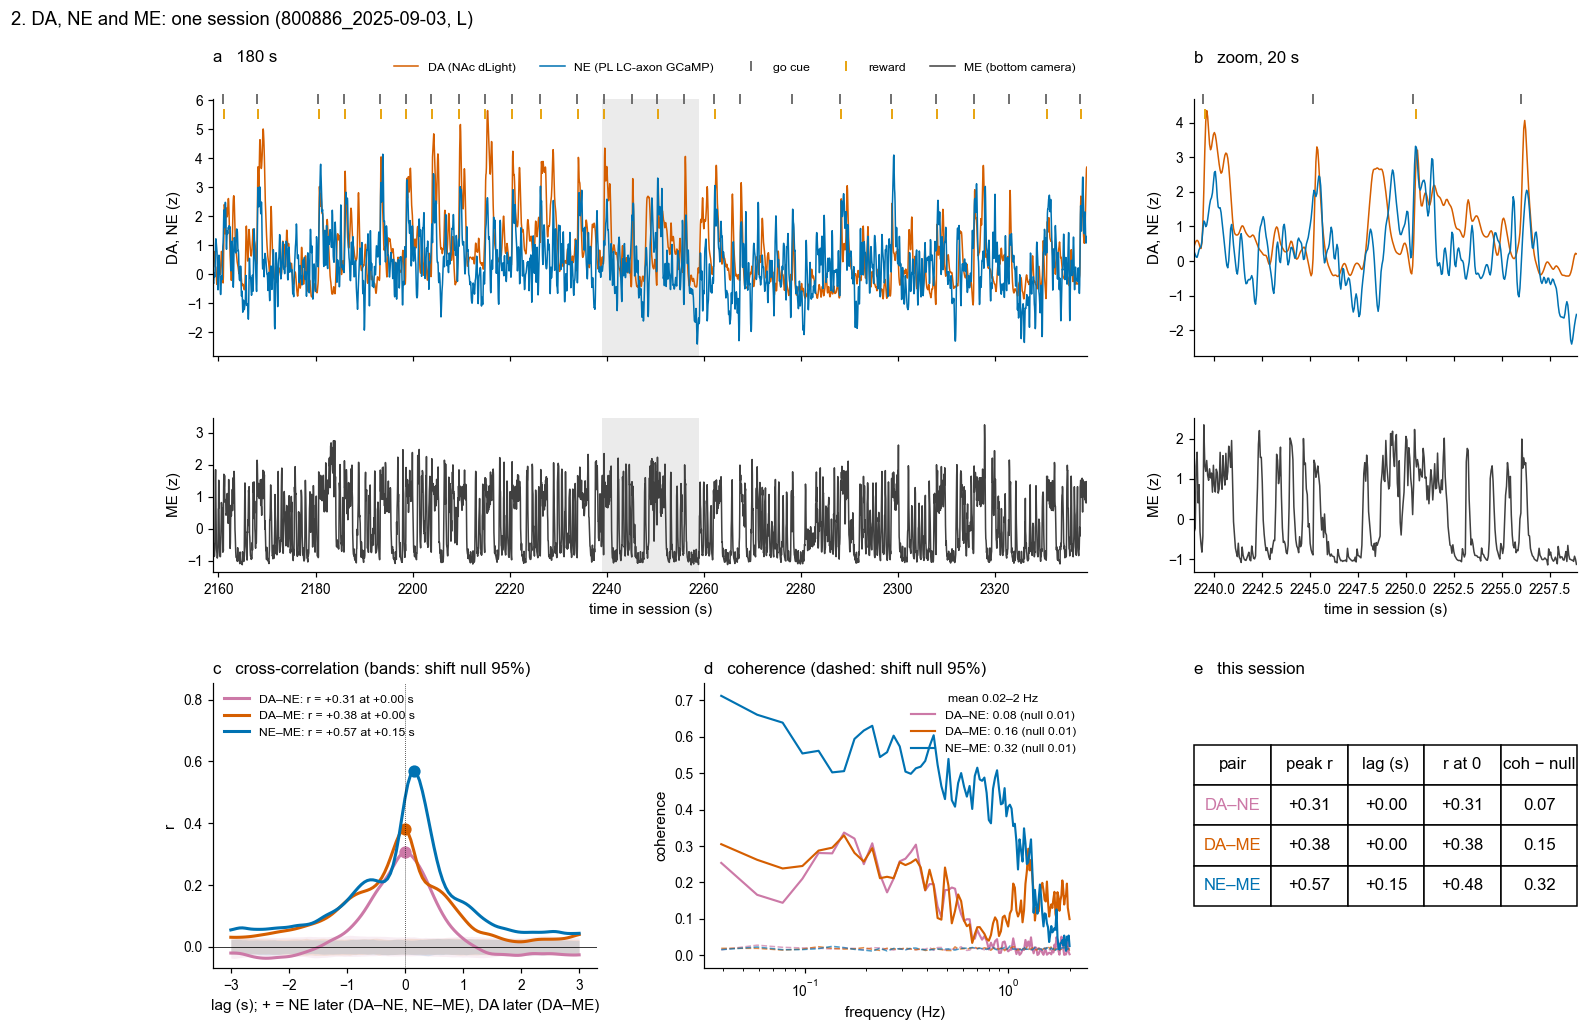

In [8]:
ex_names = [p["session"] for p in me_pairs]
dane = pair_sess[pair_sess.pair == PAIR_KEY[("ne", "da")]].reset_index(drop=True)
if EXAMPLE_SESSION in ex_names:
    ex_i = ex_names.index(EXAMPLE_SESSION)
else:
    ex_i = int(np.argmin(np.abs(dane.peak_r - dane.peak_r.median())))
ex = me_pairs[ex_i]
ex_rows = pair_sess[pair_sess.session == ex["session"]].set_index("pair")
ex_t = ex["t0"] + np.arange(len(ex["da"])) / FS   # session time of each grid sample
t_mid = 0.5 * (ex_t[0] + ex_t[-1])
win_a = (t_mid - EXAMPLE_WINDOW_S / 2, t_mid + EXAMPLE_WINDOW_S / 2)
win_z = (t_mid - EXAMPLE_ZOOM_S / 2, t_mid + EXAMPLE_ZOOM_S / 2)


def plot_event_ticks(ax, p, win, legend=False):
    tr = p["trials"]
    for col, sel, c, lab, yy in ((CUE, np.ones(len(tr), bool), PALETTE["neutral"], "go cue", 1.0),
                                 ("reward_outcome_time_in_session", tr["earned_reward"].astype(bool),
                                  OUT_COLOR["rewarded"], "reward", 0.94)):
        t = tr.loc[sel, col].dropna().to_numpy()
        t = t[(t >= win[0]) & (t < win[1])]
        ax.plot(t, np.full(len(t), yy), "|", color=c, ms=7, mew=1.2, label=lab,
                transform=ax.get_xaxis_transform(), clip_on=False)


def plot_example_traces(ax_top, ax_me, p, win, shade=None, legend=False):
    t = p["t0"] + np.arange(len(p["da"])) / FS
    m = (t >= win[0]) & (t < win[1])
    for s in ("da", "ne"):
        ax_top.plot(t[m], p["z"][s][m], color=SIG_COLOR[s], lw=1.0, label=SIG_LABEL[s])
    ax_me.plot(t[m], p["z"]["me"][m], color=SIG_COLOR["me"], lw=1.0, label=SIG_LABEL["me"])
    plot_event_ticks(ax_top, p, win)
    for ax in (ax_top, ax_me):
        if shade:
            ax.axvspan(*shade, color=NULL_COLOR, alpha=0.2, lw=0)
        ax.set_xlim(win)
        style_ax(ax)
    ax_top.set_ylabel("DA, NE (z)")
    ax_me.set_ylabel("ME (z)")
    ax_top.tick_params(labelbottom=False)
    ax_me.set_xlabel("time in session (s)")
    if legend:
        h = ax_top.get_legend_handles_labels()
        h2 = ax_me.get_legend_handles_labels()
        ax_top.legend(h[0] + h2[0], h[1] + h2[1], loc="lower right", bbox_to_anchor=(1.0, 1.06),
                      ncol=5, frameon=False, fontsize=8)


fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig, height_ratios=[1.0, 0.6, 1.3], hspace=0.25, wspace=0.28, top=0.9)
gs_bottom = GridSpec(3, 3, figure=fig, height_ratios=[1.0, 0.6, 1.3], hspace=0.55, wspace=0.28, top=0.9)

ax = fig.add_subplot(gs[0, :2]); ax2 = fig.add_subplot(gs[1, :2], sharex=ax)
plot_example_traces(ax, ax2, ex, win_a, shade=win_z, legend=True)
ax.set_title(f"a   {EXAMPLE_WINDOW_S:.0f} s", loc="left", pad=24)
ax = fig.add_subplot(gs[0, 2]); ax2 = fig.add_subplot(gs[1, 2], sharex=ax)
plot_example_traces(ax, ax2, ex, win_z)
ax.set_title(f"b   zoom, {EXAMPLE_ZOOM_S:.0f} s", loc="left", pad=24)

ax = fig.add_subplot(gs_bottom[2, 0])
for pr in PAIRS:
    lo, hi = pair_curves[pr]["xc_null"][ex_i]
    ax.fill_between(LAGS, lo, hi, color=PAIR_COLOR[pr], alpha=0.12, lw=0)
    r = ex_rows.loc[PAIR_KEY[pr]]
    ax.plot(LAGS, pair_curves[pr]["xc"][ex_i], color=PAIR_COLOR[pr], lw=2,
            label=f"{PAIR_LABEL[pr]}: r = {r.peak_r:+.2f} at {r.peak_lag:+.2f} s")
    ax.plot(r.peak_lag, r.peak_r, "o", color=PAIR_COLOR[pr], ms=7)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag (s); + = NE later (DA–NE, NE–ME), DA later (DA–ME)")
ax.set_ylabel("r")
ax.set_title("c   cross-correlation (bands: shift null 95%)", loc="left")
ax.set_ylim(top=1.5 * ex_rows["peak_r"].abs().max())   # headroom for the legend
ax.legend(fontsize=8, loc="upper left", frameon=False)
style_ax(ax)

ax = fig.add_subplot(gs_bottom[2, 1])
for pr in PAIRS:
    r = ex_rows.loc[PAIR_KEY[pr]]
    ax.semilogx(f_coh[IN_F], pair_curves[pr]["coh"][ex_i][IN_F], color=PAIR_COLOR[pr], lw=1.4,
                label=f"{PAIR_LABEL[pr]}: {r.coh_band:.2f} (null {r.coh_band - r.coh_effect:.2f})")
    ax.semilogx(f_coh[IN_F], pair_curves[pr]["coh_null"][ex_i][IN_F], color=PAIR_COLOR[pr], lw=1,
                ls="--", alpha=0.7)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title("d   coherence (dashed: shift null 95%)", loc="left")
ax.legend(fontsize=8, loc="upper right", frameon=False, title="mean 0.02–2 Hz", title_fontsize=8)
style_ax(ax)

ax = fig.add_subplot(gs_bottom[2, 2])
ax.axis("off")
cells = [[PAIR_LABEL[pr], f"{ex_rows.loc[PAIR_KEY[pr], 'peak_r']:+.2f}",
          f"{ex_rows.loc[PAIR_KEY[pr], 'peak_lag']:+.2f}", f"{ex_rows.loc[PAIR_KEY[pr], 'r0']:+.2f}",
          f"{ex_rows.loc[PAIR_KEY[pr], 'coh_effect']:.2f}"] for pr in PAIRS]
tbl = ax.table(cellText=cells, colLabels=["pair", "peak r", "lag (s)", "r at 0", "coh − null"],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.2)
for k, pr in enumerate(PAIRS):
    tbl[k + 1, 0].get_text().set_color(PAIR_COLOR[pr])
ax.set_title("e   this session", loc="left")

fig.suptitle(f"2. DA, NE and ME: one session ({ex['session']}, {ex['side']})", x=0.01, ha="left")
save_fig(fig, "fip_10_2_pairs_example", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

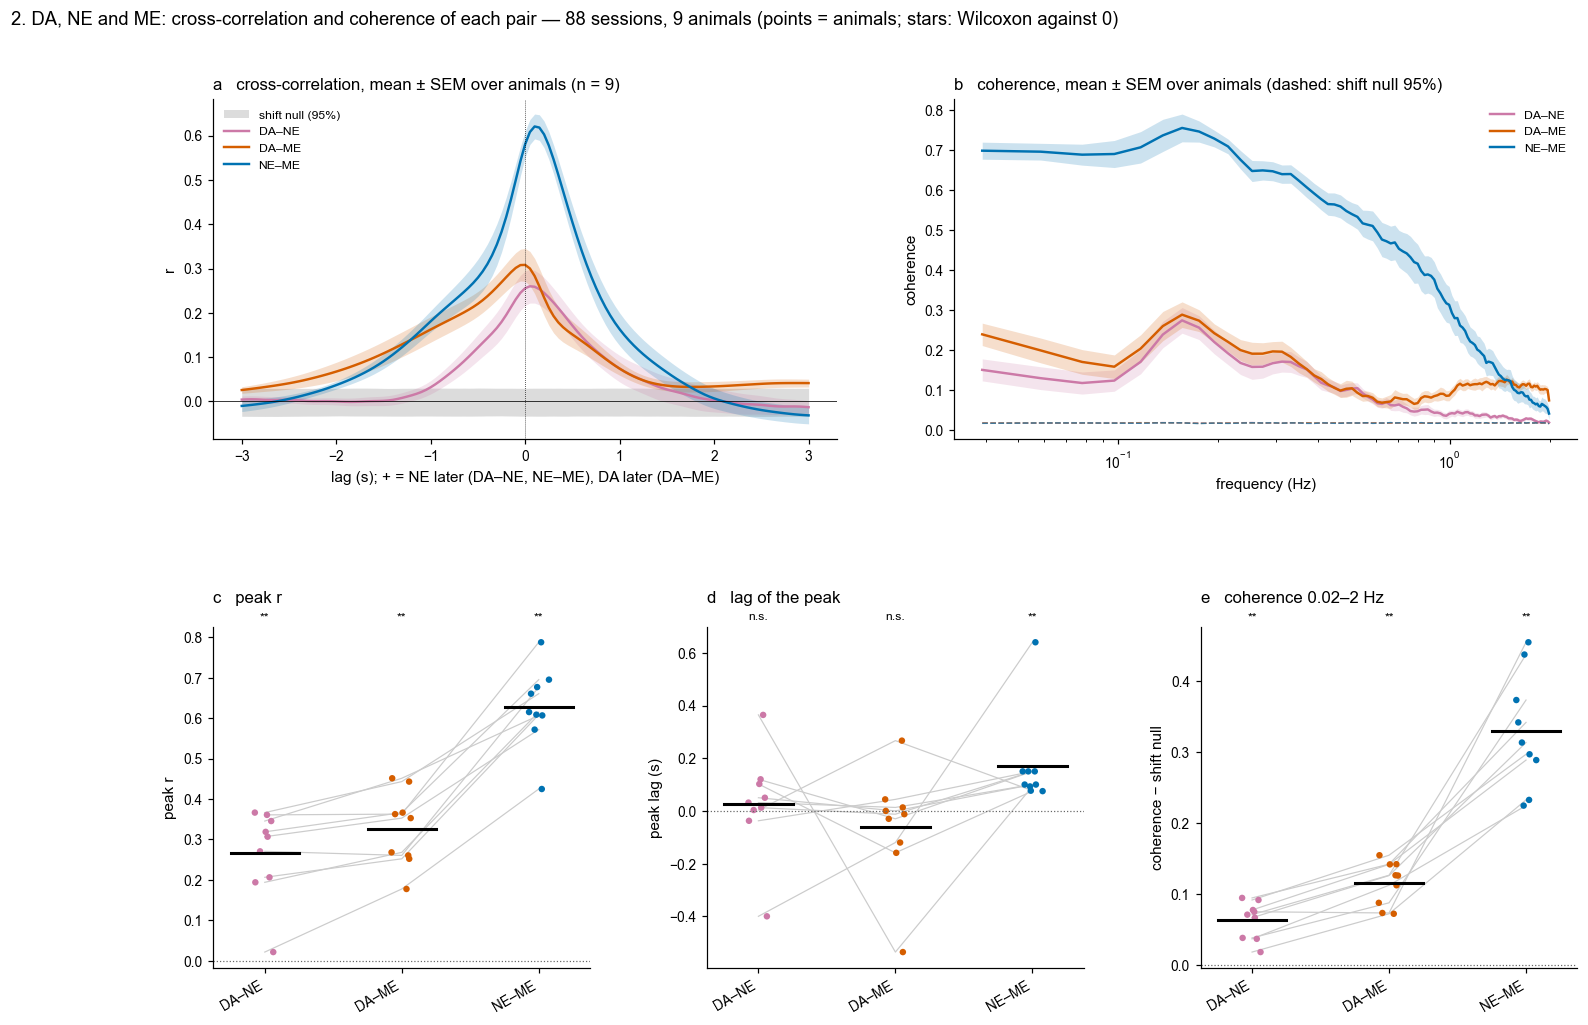

In [9]:
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 6, figure=fig, hspace=0.55, wspace=0.9, top=0.9)

ax = fig.add_subplot(gs[0, :3])
lo = np.min([pair_xc_null[pr][0] for pr in PAIRS], 0)
hi = np.max([pair_xc_null[pr][1] for pr in PAIRS], 0)
ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
for pr in PAIRS:
    pu.plot_mean_sem(ax, LAGS, list(pair_xc[pr]), PAIR_COLOR[pr], PAIR_LABEL[pr])
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag (s); + = NE later (DA–NE, NE–ME), DA later (DA–ME)")
ax.set_ylabel("r")
ax.set_title(f"a   cross-correlation, mean ± SEM over animals (n = {N_ME_ANIMALS})", loc="left")
ax.legend(fontsize=8, loc="upper left", frameon=False)
style_ax(ax)

ax = fig.add_subplot(gs[0, 3:])
for pr in PAIRS:
    pu.plot_mean_sem(ax, f_coh[IN_F], pair_coh[pr][:, IN_F], PAIR_COLOR[pr], PAIR_LABEL[pr])
    ax.plot(f_coh[IN_F], pair_coh_null[pr][IN_F], color=PAIR_COLOR[pr], lw=1, ls="--", alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title("b   coherence, mean ± SEM over animals (dashed: shift null 95%)", loc="left")
ax.legend(fontsize=8, loc="upper right", frameon=False)
style_ax(ax)

labels = [PAIR_LABEL[pr] for pr in PAIRS]
colors = [PAIR_COLOR[pr] for pr in PAIRS]
for k, (m, ylab, title) in enumerate((("peak_r", "peak r", "c   peak r"),
                                      ("peak_lag", "peak lag (s)", "d   lag of the peak"),
                                      ("coh_effect", "coherence − shift null", "e   coherence 0.02–2 Hz"))):
    ax = fig.add_subplot(gs[1, 2 * k:2 * k + 2])
    pu.strip_by_measure(ax, pair_animal, [f"{m}_{PAIR_KEY[pr]}" for pr in PAIRS], labels, colors,
                        ylab, title)

fig.suptitle(f"2. DA, NE and ME: cross-correlation and coherence of each pair — {len(me_pairs)} sessions, "
             f"{N_ME_ANIMALS} animals (points = animals; stars: Wilcoxon against 0)", x=0.01, ha="left")
save_fig(fig, "fip_10_2_pairs_summary", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

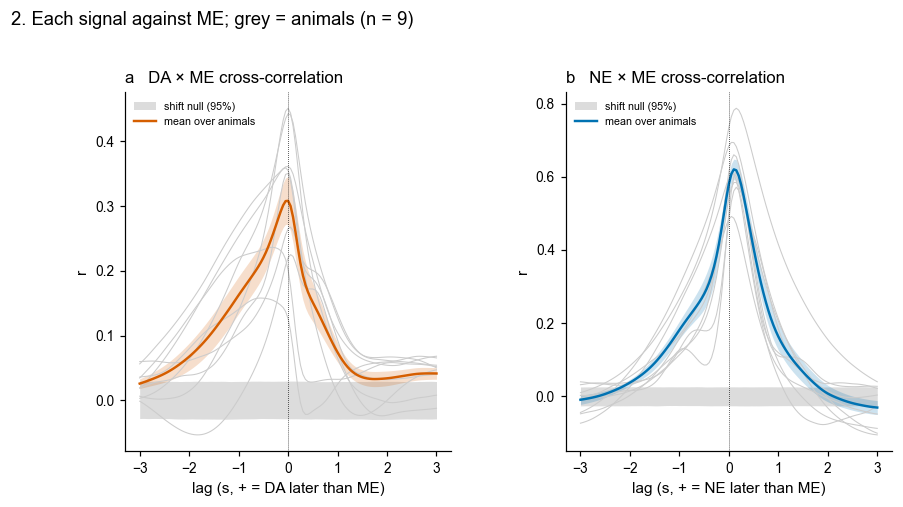

In [10]:
# DA × ME and NE × ME, each animal's curve (the same cross-correlations as the summary figure)
fig = plt.figure(figsize=(9, 4.6))
gs = GridSpec(1, 2, figure=fig, wspace=0.35, top=0.82)
for j, s in enumerate(("da", "ne")):
    ax = fig.add_subplot(gs[j])
    c = pair_curves[(s, "me")]
    lo = st.group_means([b[0] for b in c["xc_null"]], ME_SUBJECTS)[1].mean(0)
    hi = st.group_means([b[1] for b in c["xc_null"]], ME_SUBJECTS)[1].mean(0)
    ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
    for curve in pair_xc[(s, "me")]:
        ax.plot(LAGS, curve, color="0.8", lw=0.7)
    pu.plot_mean_sem(ax, LAGS, pair_xc[(s, "me")], SIG_COLOR[s], "mean over animals")
    ax.axvline(0, color="k", lw=0.5, ls=":")
    ax.set_xlabel(f"lag (s, + = {s.upper()} later than ME)")
    ax.set_ylabel("r")
    ax.set_title(f"{'ab'[j]}   {s.upper()} × ME cross-correlation", loc="left")
    ax.legend(fontsize=7, loc="upper left")
    style_ax(ax)
fig.suptitle(f"2. Each signal against ME; grey = animals (n = {N_ME_ANIMALS})", x=0.01, ha="left")
save_fig(fig, "fip_10_2_signal_me_xcorr", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

### 2, by band

Coherence of each pair in three bands, observed minus the shift-null median, one point per animal.
**a** the animal-mean coherence spectra with the bands marked; **b** the band profile of each pair
(mean ± SEM over animals); **c–e** one panel per band.

fraction of sessions above their shift null (p < 0.05), by band
       p_coh[0.02–0.1 Hz]  p_coh[0.1–0.5 Hz]  p_coh[0.5–2 Hz]
pair                                                         
da_me                1.00                1.0              1.0
ne_da                0.98                1.0              1.0
ne_me                1.00                1.0              1.0 

── coherence − null, 0.02–0.1 Hz
                      measure  mean    sem       p  n
coh_effect[0.02–0.1 Hz]_ne_da 0.127 0.0257 0.00391  9
coh_effect[0.02–0.1 Hz]_da_me 0.197 0.0277 0.00391  9
coh_effect[0.02–0.1 Hz]_ne_me 0.684 0.0229 0.00391  9

── coherence − null, 0.1–0.5 Hz
                     measure  mean    sem       p  n
coh_effect[0.1–0.5 Hz]_ne_da 0.161 0.0219 0.00391  9
coh_effect[0.1–0.5 Hz]_da_me 0.177 0.0214 0.00391  9
coh_effect[0.1–0.5 Hz]_ne_me 0.639 0.0214 0.00391  9

── coherence − null, 0.5–2 Hz
                   measure   mean     sem       p  n
coh_effect[0.5–2 Hz]_ne_da 0.0351 0.00582 0.00

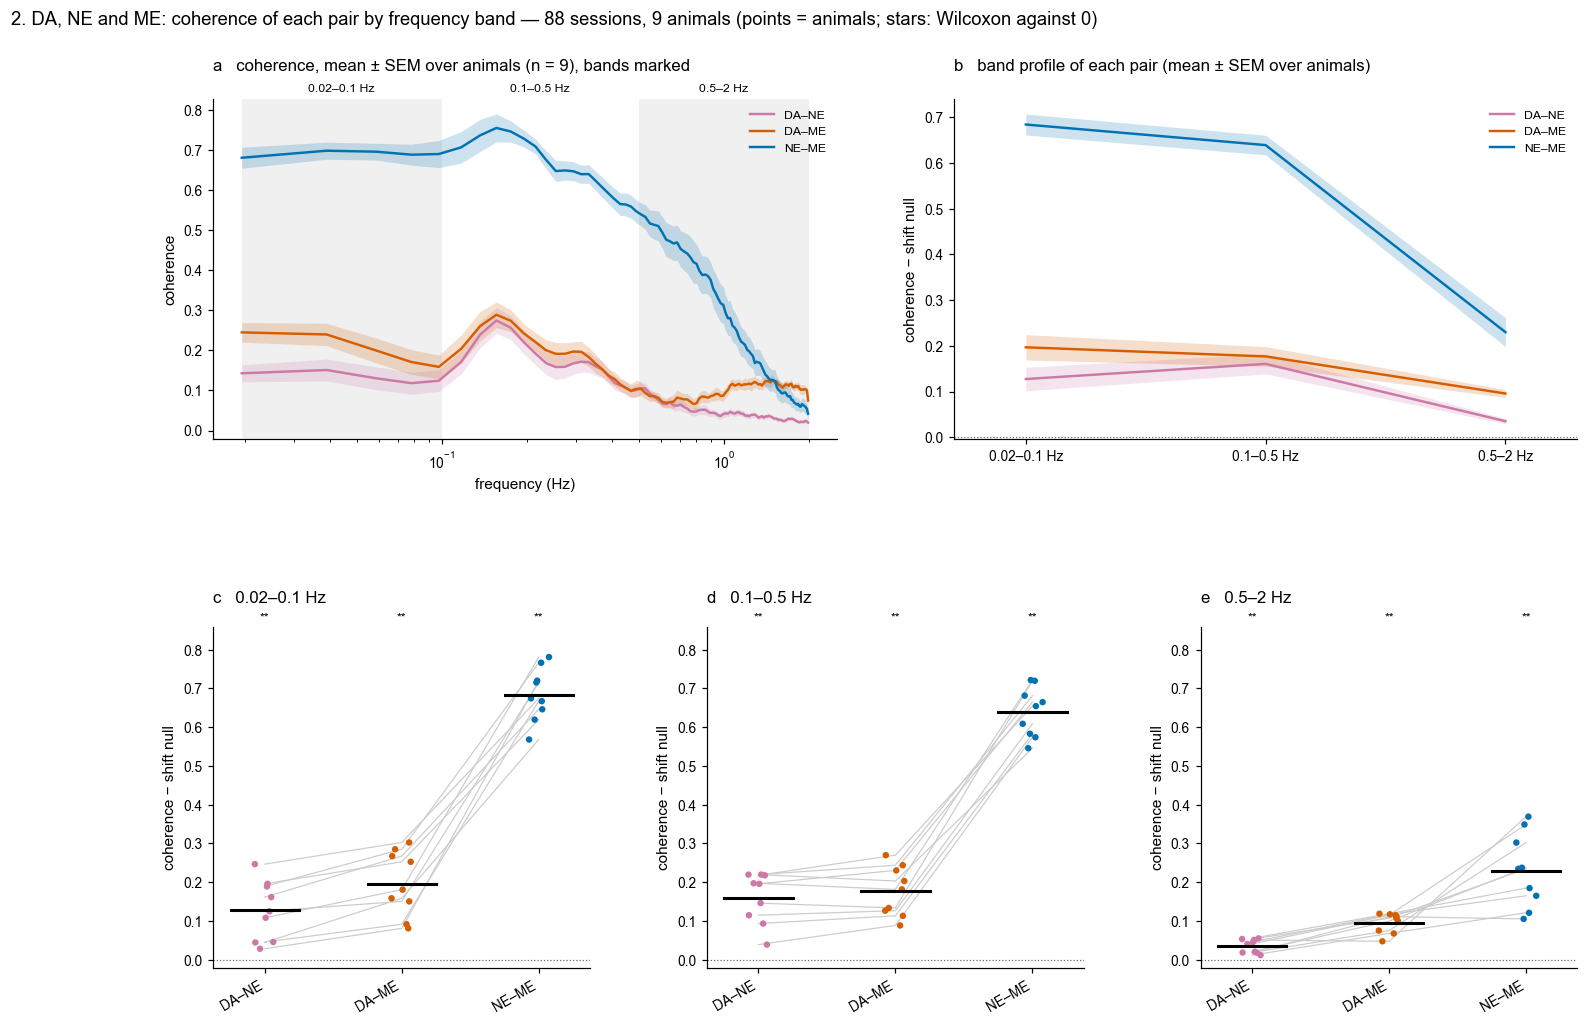

In [11]:
BAND_NAMES = list(COH_BANDS)
band_cols = [f"coh_effect[{b}]" for b in BAND_NAMES]
band_wide = pair_sess.pivot_table(index=["subject", "session"], columns="pair", values=band_cols)
band_wide.columns = [f"{m}_{pk}" for m, pk in band_wide.columns]
band_animal = st.animal_means(band_wide.reset_index(), list(band_wide.columns), by_session=False)

print("fraction of sessions above their shift null (p < 0.05), by band")
print(pair_sess.groupby("pair")[[f"p_coh[{b}]" for b in BAND_NAMES]].agg(lambda v: (v < 0.05).mean()).round(2), "\n")
for b in BAND_NAMES:
    report(f"coherence − null, {b}", band_animal, [f"coh_effect[{b}]_{PAIR_KEY[pr]}" for pr in PAIRS])
cmp_rows = []
for b in BAND_NAMES:
    for i, x in enumerate(PAIRS):
        for y in PAIRS[i + 1:]:
            d = band_animal[f"coh_effect[{b}]_{PAIR_KEY[x]}"] - band_animal[f"coh_effect[{b}]_{PAIR_KEY[y]}"]
            mean, pv, n = st.wilcoxon_animals(d)
            cmp_rows.append(dict(band=b, comparison=f"{PAIR_LABEL[x]} − {PAIR_LABEL[y]}", mean_diff=mean, p=pv,
                                 animals_positive=f"{int((d > 0).sum())}/{n}"))
band_cmp = pd.DataFrame(cmp_rows)
print("── pair against pair, by band (Wilcoxon on animal differences)")
print(band_cmp.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 6, figure=fig, hspace=0.55, wspace=0.9, top=0.9)

ax = fig.add_subplot(gs[0, :3])
pos_f = f_coh > 0
for k, (lo, hi) in enumerate(COH_BANDS.values()):
    if k % 2 == 0:
        ax.axvspan(lo, hi, color=NULL_COLOR, alpha=0.15, lw=0)
for pr in PAIRS:
    pu.plot_mean_sem(ax, f_coh[pos_f & (f_coh < 2.0)], pair_coh[pr][:, pos_f & (f_coh < 2.0)],
                     PAIR_COLOR[pr], PAIR_LABEL[pr])
for name, (lo, hi) in COH_BANDS.items():
    ax.text(np.sqrt(lo * hi), 1.02, name, transform=ax.get_xaxis_transform(), ha="center", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title(f"a   coherence, mean ± SEM over animals (n = {N_ME_ANIMALS}), bands marked", loc="left", pad=18)
ax.legend(fontsize=8, loc="upper right", frameon=False)
style_ax(ax)

ax = fig.add_subplot(gs[0, 3:])
xb = np.arange(len(BAND_NAMES))
for pr in PAIRS:
    pu.plot_mean_sem(ax, xb, band_animal[[f"coh_effect[{b}]_{PAIR_KEY[pr]}" for b in BAND_NAMES]].to_numpy(),
                     PAIR_COLOR[pr], PAIR_LABEL[pr])
ax.set_xticks(xb)
ax.set_xticklabels(BAND_NAMES)
ax.set_xlim(-0.3, len(BAND_NAMES) - 0.7)
ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
ax.set_ylabel("coherence − shift null")
ax.set_title("b   band profile of each pair (mean ± SEM over animals)", loc="left", pad=18)
ax.legend(fontsize=8, loc="upper right", frameon=False)
style_ax(ax)

labels = [PAIR_LABEL[pr] for pr in PAIRS]
colors = [PAIR_COLOR[pr] for pr in PAIRS]
y_hi = band_animal.max().max() * 1.1
for k, b in enumerate(BAND_NAMES):
    ax = fig.add_subplot(gs[1, 2 * k:2 * k + 2])
    pu.strip_by_measure(ax, band_animal, [f"coh_effect[{b}]_{PAIR_KEY[pr]}" for pr in PAIRS], labels, colors,
                        "coherence − shift null", f"{'cde'[k]}   {b}")
    ax.set_ylim(-0.02, y_hi)

fig.suptitle(f"2. DA, NE and ME: coherence of each pair by frequency band — {len(me_pairs)} sessions, "
             f"{N_ME_ANIMALS} animals (points = animals; stars: Wilcoxon against 0)", x=0.01, ha="left")
save_fig(fig, "fip_10_2_pairs_bands", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 3. Numbers

One row per measure: mean of animal means, Wilcoxon p against zero, animals positive, and the
fraction of sessions above their shift null (p < 0.05).

In [12]:
def row(section, measure, df, col, p=None):
    # animal means of a per-session column: mean, Wilcoxon p against 0, animals positive, and the
    # fraction of sessions with p < 0.05 where a per-session test exists
    v = df.groupby("subject")[col].mean()
    m, pv, n = st.wilcoxon_animals(v)
    out = dict(section=section, measure=measure, mean=round(m, 3), p=round(pv, 4),
               animals_positive=f"{int((v > 0).sum())}/{n}", sessions_p_lt_05="")
    if p is not None:
        d = df[[col, p]].dropna()
        out["sessions_p_lt_05"] = f"{int((d[p] < 0.05).sum())}/{len(d)}"
    return out


S = [row("1", "DA–NE peak r", xc_sess, "peak_r", "p_xc"),
     row("1", "DA–NE peak |r| minus shift-null median", xc_sess, "peak_r_effect", "p_xc"),
     row("1", "DA–NE peak lag (s, + = NE later)", xc_sess, "peak_lag"),
     row("1", "DA–NE zero-lag r", xc_sess, "r0"),
     row("1", "DA–NE coherence 0.02–2 Hz minus shift-null median", xc_sess, "coh_effect", "p_coh")]
for pr in PAIRS:
    g = pair_sess[pair_sess.pair == PAIR_KEY[pr]]
    S += [row("2", f"{PAIR_LABEL[pr]} peak r", g, "peak_r", "p_xc"),
          row("2", f"{PAIR_LABEL[pr]} peak lag (s)", g, "peak_lag"),
          row("2", f"{PAIR_LABEL[pr]} coherence 0.02–2 Hz minus null", g, "coh_effect", "p_coh")]
    S += [row("2", f"{PAIR_LABEL[pr]} coherence minus null, {b}", g, f"coh_effect[{b}]", f"p_coh[{b}]")
          for b in COH_BANDS]
pd.DataFrame(S).set_index(["section", "measure"])

mean       p animals_positive sessions_p_lt_05
section measure                                                                                           
1       DA–NE peak r                                       0.272  0.0039              9/9            97/97
        DA–NE peak |r| minus shift-null median             0.255  0.0039              9/9            97/97
        DA–NE peak lag (s, + = NE later)                   0.023  0.3270              6/9                 
        DA–NE zero-lag r                                   0.260  0.0039              9/9                 
        DA–NE coherence 0.02–2 Hz minus shift-null median  0.064  0.0039              9/9            97/97
2       DA–NE peak r                                       0.265  0.0039              9/9            88/88
        DA–NE peak lag (s)                                 0.027  0.3008              7/9                 
        DA–NE coherence 0.02–2 Hz minus null               0.063  0.0039              9/9            88/88
        DA–NE coherence minus null, 0.02–0.1 Hz            0.127  0.0039              9/9            86/88
        DA–NE coherence minus null, 0.1–0.5 Hz             0.161  0.0039              9/9            88/88
        DA–NE coherence minus null, 0.5–2 Hz               0.035  0.0039              9/9            88/88
        DA–ME peak r                                       0.326  0.0039              9/9            88/88
        DA–ME peak lag (s)                                -0.059  0.4838              3/9                 
        DA–ME coherence 0.02–2 Hz minus null               0.115  0.0039              9/9            88/88
        DA–ME coherence minus null, 0.02–0.1 Hz            0.197  0.0039              9/9            88/88
        DA–ME coherence minus null, 0.1–0.5 Hz             0.177  0.0039              9/9            88/88
        DA–ME coherence minus null, 0.5–2 Hz               0.096  0.0039              9/9            88/88
        NE–ME peak r                                       0.627  0.0039              9/9            88/88
        NE–ME peak lag (s)                                 0.171  0.0039              9/9                 
        NE–ME coherence 0.02–2 Hz minus null               0.329  0.0039              9/9            88/88
        NE–ME coherence minus null, 0.02–0.1 Hz            0.684  0.0039              9/9            88/88
        NE–ME coherence minus null, 0.1–0.5 Hz             0.639  0.0039              9/9            88/88
        NE–ME coherence minus null, 0.5–2 Hz               0.230  0.0039              9/9            88/88